# Global Earthquakes 2020–2026: A Visual Exploration

11,808 magnitude 5.0+ earthquakes worldwide, cleaned from the USGS Earthquake Catalog. Full cleaning methodology and column documentation live in the companion dataset: [Global Earthquakes 2020-2026 (M5.0+, USGS, Cleaned)](https://www.kaggle.com/datasets/zaneneave/global-earthquakes-2020-2026)

This notebook explores:
- Where earthquakes cluster globally
- How frequency has trended over time
- Whether depth and magnitude relate
- Seasonal/monthly patterns (or lack thereof)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.facecolor"] = "#0d1117"
plt.rcParams["axes.facecolor"] = "#161b22"
plt.rcParams["axes.edgecolor"] = "#30363d"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["text.color"] = "white"
plt.rcParams["xtick.color"] = "#8b949e"
plt.rcParams["ytick.color"] = "#8b949e"
plt.rcParams["axes.titlecolor"] = "white"
plt.rcParams["grid.color"] = "#21262d"

df = pd.read_csv("/kaggle/input/datasets/zaneneave/global-earthquakes-2020-2026/global_earthquakes_2020_2026.csv")

df["time"] = pd.to_datetime(df["time"], format="ISO8601")
df["month"] = df["time"].dt.month

df["mag_category"] = pd.cut(df["mag"], bins=[5, 5.5, 6, 6.5, 7, 10],
    labels=["5.0-5.5", "5.5-6.0", "6.0-6.5", "6.5-7.0", "7.0+"],
    include_lowest=True)

print(f"{len(df):,} earthquakes loaded | {df['time'].min().date()} to {df['time'].max().date()}")
print("Null mag_category:", df["mag_category"].isnull().sum())

df.head()

11,808 earthquakes loaded | 2020-01-01 to 2026-07-14
Null mag_category: 0


,id,time,year,decade,latitude,longitude,depth,mag,magType,place,...,nst,gap,dmin,rms,horizontalError,depthError,magError,status,net,month
0,us70006t13,2020-01-01 00:28:20.289000+00:00,2020,2020,-5.3245,152.5514,40.24,5.1,mb,"112 km SSE of Kokopo, Papua New Guinea",...,NaN,74.0,1.190,0.79,9.4,6.3,0.044,reviewed,us,1
1,us70006t2a,2020-01-01 03:53:29.023000+00:00,2020,2020,52.6367,159.1614,58.46,5.0,mb,"56 km SE of Petropavlovsk-Kamchatsky, Russia",...,NaN,94.0,0.496,0.66,7.7,4.6,0.026,reviewed,us,1
2,us70006t3c,2020-01-01 08:31:24.136000+00:00,2020,2020,-17.4280,-172.5044,10.00,5.4,mww,"207 km NE of Neiafu, Tonga",...,NaN,40.0,2.947,1.44,8.8,1.8,0.086,reviewed,us,1
3,us70006t6a,2020-01-01 16:34:59.178000+00:00,2020,2020,-53.0907,9.5001,10.00,5.0,mb,southwest of Africa,...,NaN,105.0,19.424,0.83,14.0,1.9,0.082,reviewed,us,1
4,us70006t6h,2020-01-01 16:51:32.285000+00:00,2020,2020,-30.2857,-71.5582,40.88,5.0,mwr,"42 km SSW of Coquimbo, Chile",...,NaN,117.0,0.392,0.72,5.0,2.5,0.038,reviewed,us,1


## Quick Overview

Before mapping anything, a snapshot of the shape of the data: how strong these earthquakes typically are, how deep, how frequent per year and where most activity is concentrated.

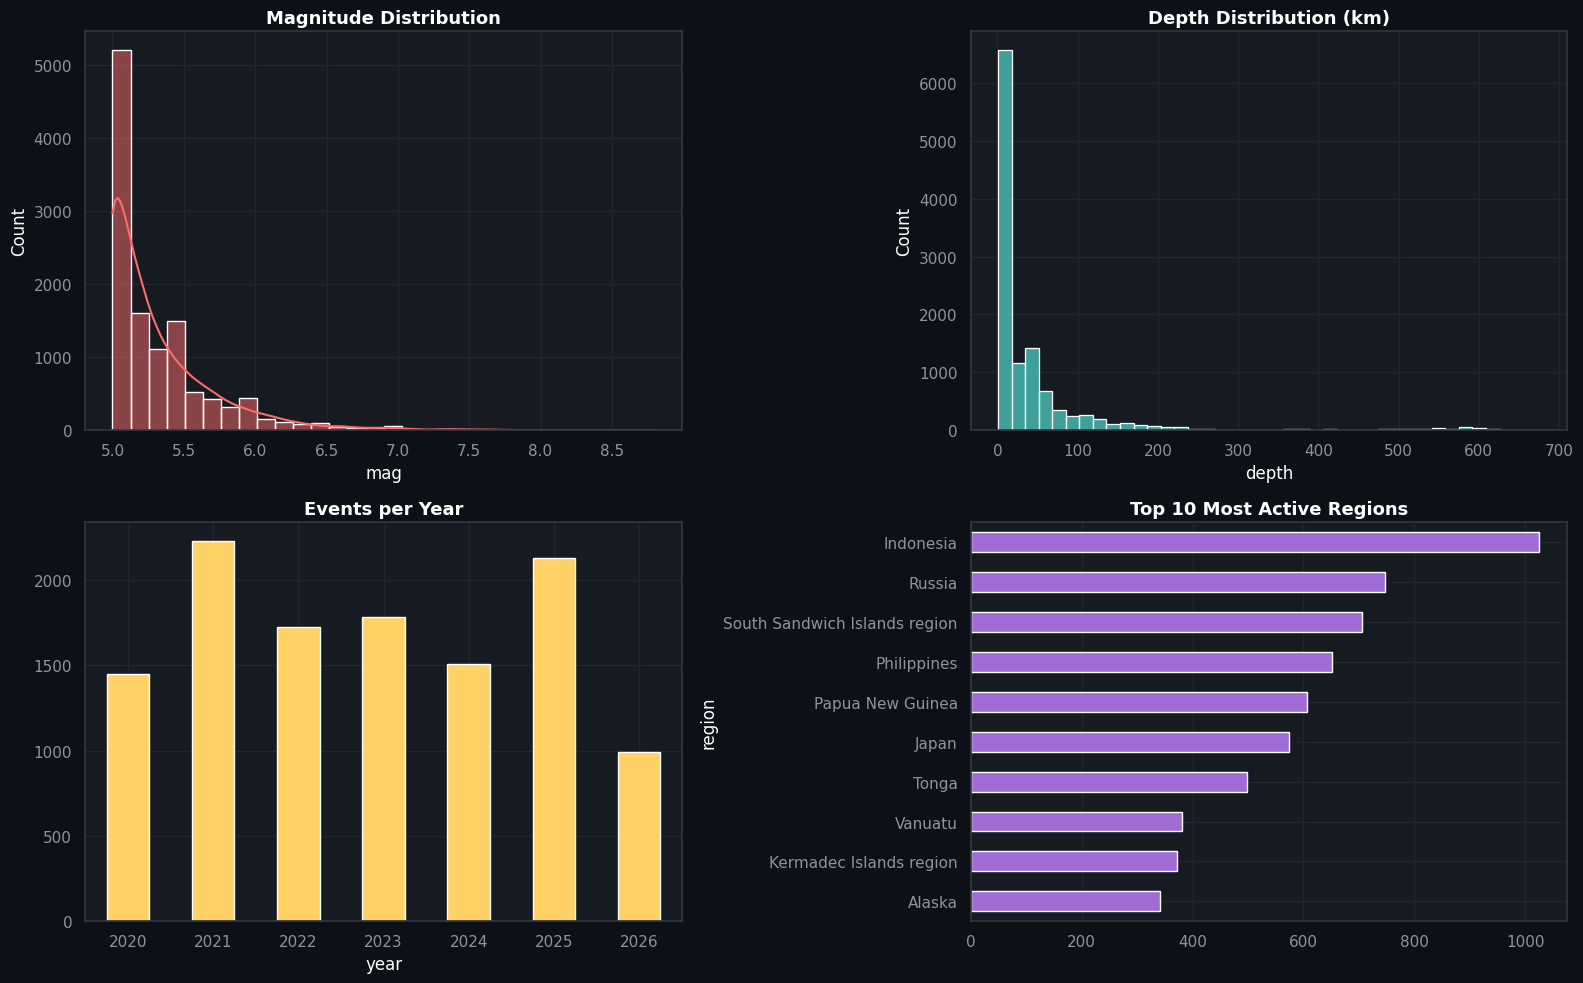

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df["mag"], bins=30, kde=True, color="#ff6b6b", ax=axes[0,0])
axes[0,0].set_title("Magnitude Distribution", fontsize=13, fontweight="bold")

sns.histplot(df["depth"], bins=40, color="#4ecdc4", ax=axes[0,1])
axes[0,1].set_title("Depth Distribution (km)", fontsize=13, fontweight="bold")

df["year"].value_counts().sort_index().plot(kind="bar", color="#ffd166", ax=axes[1,0])
axes[1,0].set_title("Events per Year", fontsize=13, fontweight="bold")
axes[1,0].tick_params(axis='x', rotation=0)

df["region"].value_counts().head(10).plot(kind="barh", color="#a06cd5", ax=axes[1,1])
axes[1,1].invert_yaxis()
axes[1,1].set_title("Top 10 Most Active Regions", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

## Mapping the Ring of Fire

Earthquakes aren't randomly distributed, they trace tectonic plate boundaries almost exactly. Below, every event in the dataset plotted by coordinates, sized and colored by magnitude.

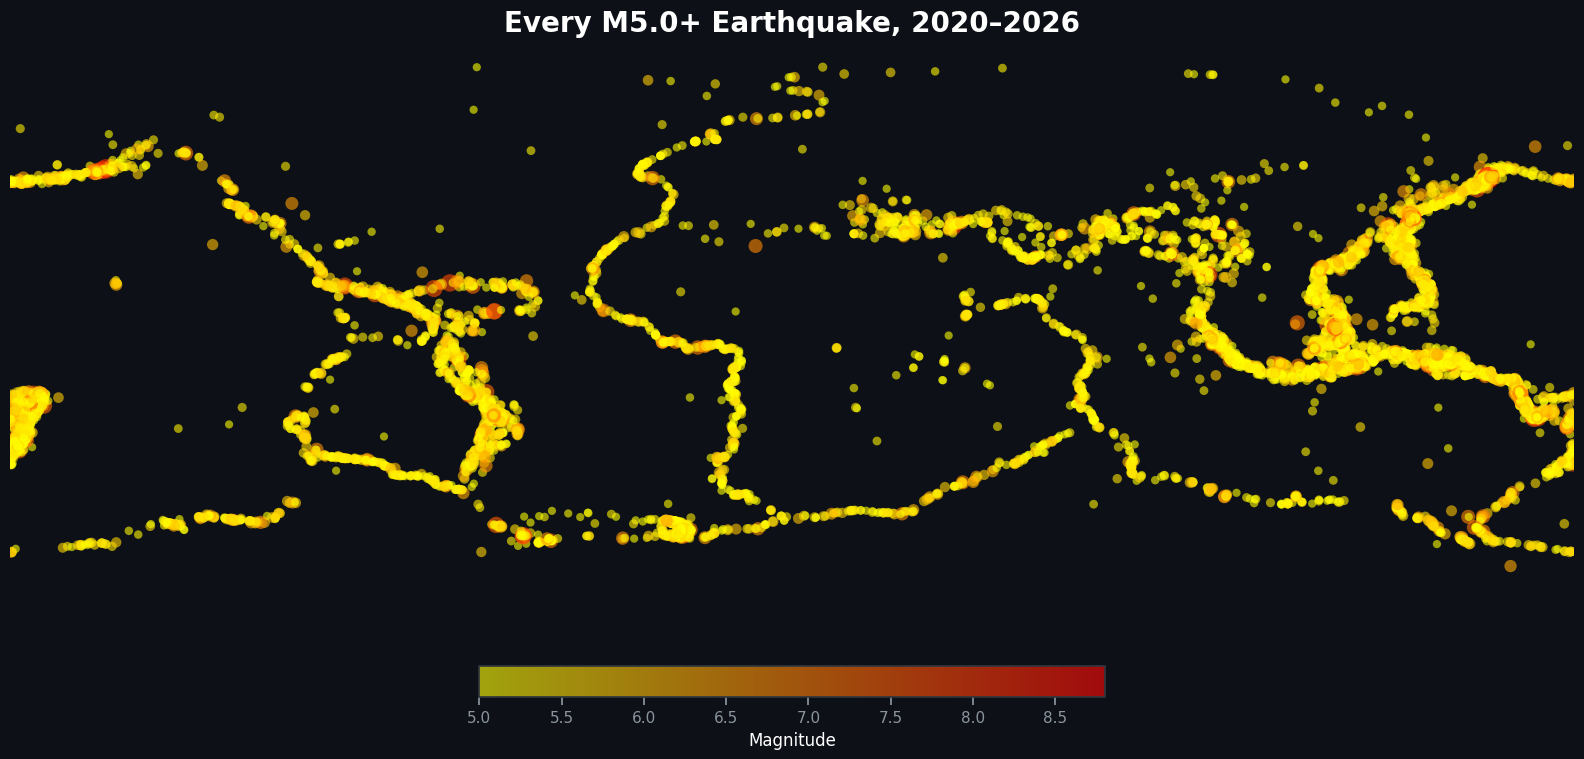

In [3]:
fig, ax = plt.subplots(figsize=(16, 8), facecolor="#0d1117")
ax.set_facecolor("#0d1117")

scatter = ax.scatter(
    df["longitude"], df["latitude"],
    s=df["mag"] ** 3.5 / 8,
    c=df["mag"], cmap="autumn_r", alpha=0.6, edgecolors="none"
)
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xticks([]); ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

cbar = plt.colorbar(scatter, ax=ax, orientation="horizontal", pad=0.05, shrink=0.4)
cbar.set_label("Magnitude", color="white")

ax.set_title("Every M5.0+ Earthquake, 2020–2026", fontsize=20, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

## Is seismic activity trending anywhere?

Raw daily counts are noisy, so a 90-day rolling average is layered on top to reveal the underlying trend rather than day-to-day fluctuation.

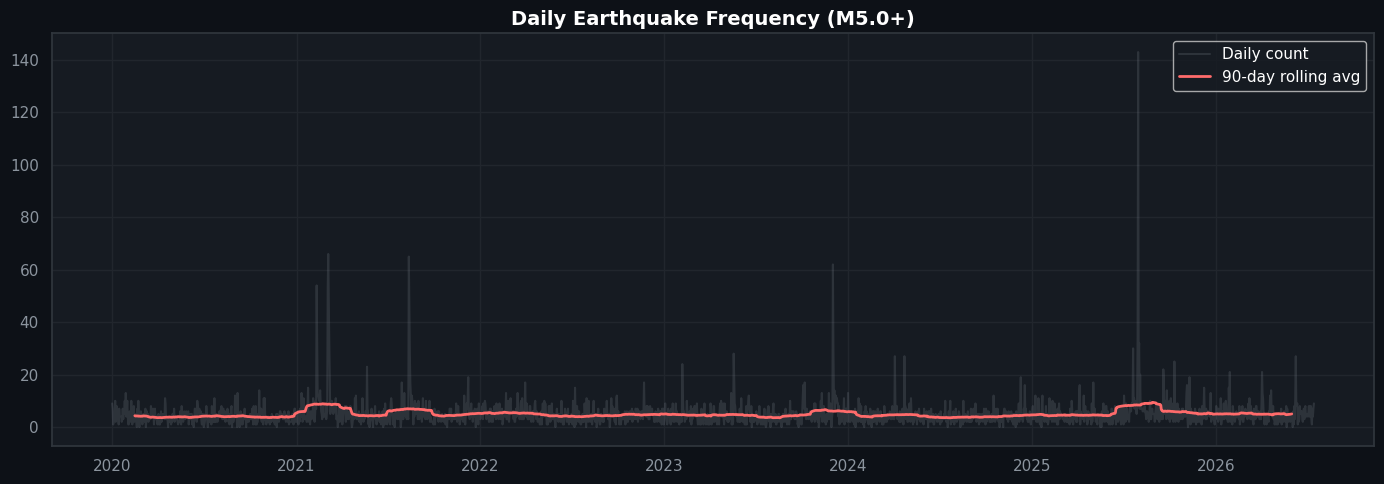

In [4]:
daily = df.set_index("time").resample("D").size()
rolling = daily.rolling(90, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily.index, daily.values, alpha=0.2, color="#8b949e", label="Daily count")
ax.plot(rolling.index, rolling.values, color="#ff6b6b", linewidth=2, label="90-day rolling avg")
ax.set_title("Daily Earthquake Frequency (M5.0+)", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## Does time of year matter?

Physically, there's no strong reason earthquakes should follow a seasonal pattern, but it's worth checking the data directly rather than assuming.

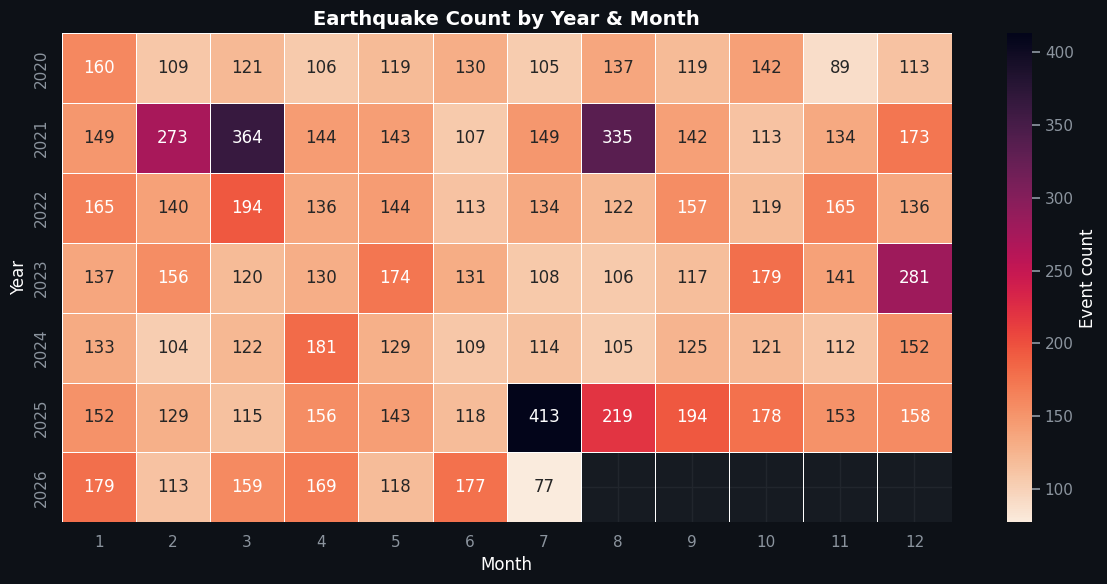

In [5]:
pivot = df.pivot_table(index="year", columns="month", values="id", aggfunc="count")

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap="rocket_r", annot=True, fmt=".0f", linewidths=0.5,
            cbar_kws={"label": "Event count"})
plt.title("Earthquake Count by Year & Month", fontsize=14, fontweight="bold")
plt.xlabel("Month"); plt.ylabel("Year")
plt.tight_layout()
plt.show()

## Depth vs. Magnitude

Shallow earthquakes are often more destructive even at the same magnitude, since they're closer to the surface. Does the data show any relationship between how deep an earthquake is and how strong it is?

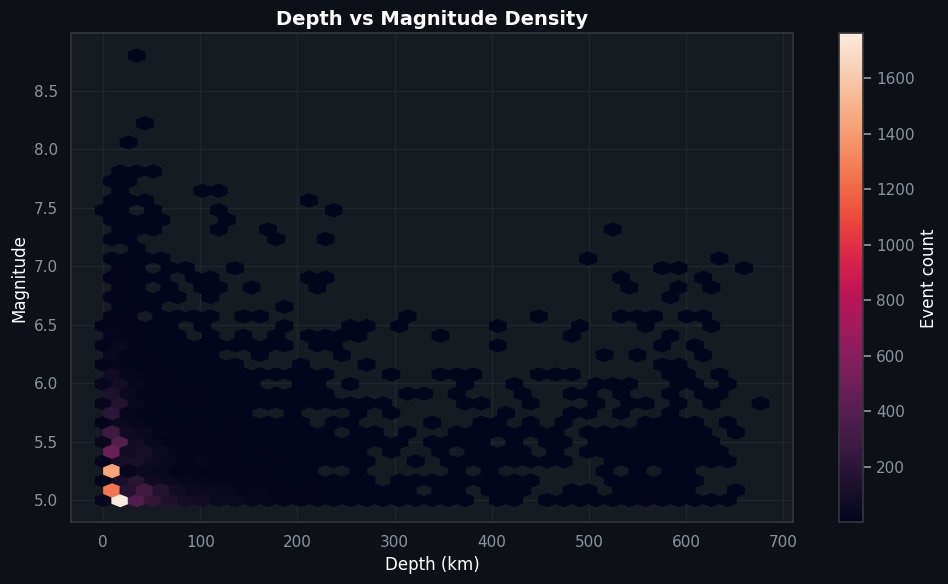

Correlation (depth, mag): 0.095


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
hb = ax.hexbin(df["depth"], df["mag"], gridsize=40, cmap="rocket", mincnt=1)
ax.set_xlabel("Depth (km)"); ax.set_ylabel("Magnitude")
ax.set_title("Depth vs Magnitude Density", fontsize=14, fontweight="bold")
plt.colorbar(hb, label="Event count")
plt.tight_layout()
plt.show()

print("Correlation (depth, mag):", round(df["depth"].corr(df["mag"]), 3))

## How do the numeric fields relate to each other?

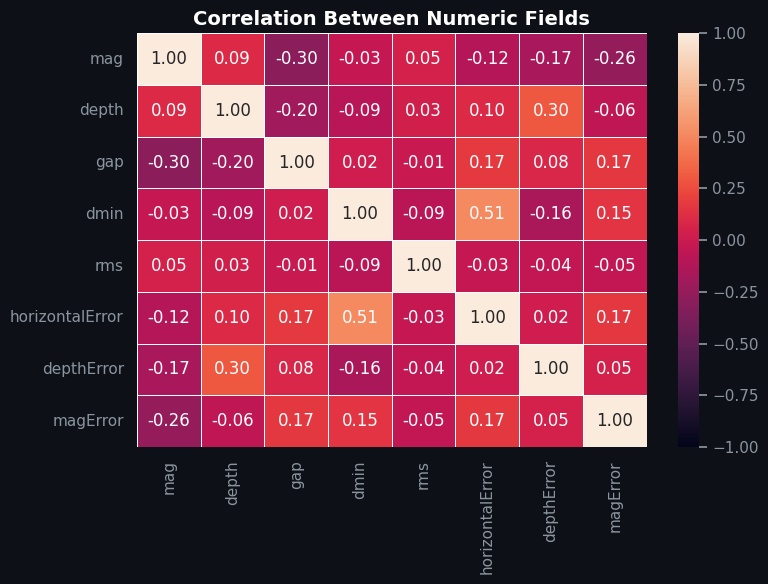

In [7]:
numeric_cols = ["mag", "depth", "gap", "dmin", "rms", "horizontalError", "depthError", "magError"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Between Numeric Fields", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Have fun